# Training Analysis Notebook

This notebook analyses training runs for the baseline/non-force-aware agents and the force-aware agents.

Before this notebook, baseline runs are normalized into one canonical merged folder per execution wire with:

```bash
python scripts/merge_non_force_aware_run_chains.py --force
```

Baseline merged root:

```text
data/archive/agents/non_force_aware/<wire_model>/<wire_shape>/merged
```

Force-aware merged root:

```text
data/archive/agents/force_aware/<wire_model>/<alpha>/merged
```

The first goal is coverage and training-curve analysis, not E2 evaluation performance. Later sections can join these training summaries with E1/E2 evaluation tables through `execution_wire`.


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Optional
import json
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display


def find_project_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / "scripts" / "merge_non_force_aware_run_chains.py").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate project root")


PROJECT_ROOT = find_project_root()
BASELINE_ROOT = PROJECT_ROOT / "data" / "archive" / "agents" / "non_force_aware"
FORCE_AWARE_ROOT = PROJECT_ROOT / "data" / "archive" / "agents" / "force_aware"

QUALITY_RE = re.compile(
    r"Quality:\s*(?P<quality>-?\d+(?:\.\d+)?)\s*,\s*Reward:\s*(?P<reward>-?\d+(?:\.\d+)?)\s*,\s*Exploration steps:\s*(?P<steps>\d+)"
)
UPDATE_RE = re.compile(r"\|\s+\d+/(?P<steps>\d+)\s+steps total")
STAGE_RE = re.compile(r"^===== STAGE (?P<stage>.+) =====$")
CHECKPOINT_RE = re.compile(r"checkpoint(?P<step>\d+)\.everl$")

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"BASELINE_ROOT exists={BASELINE_ROOT.exists()}")
print(f"FORCE_AWARE_ROOT exists={FORCE_AWARE_ROOT.exists()}")


PROJECT_ROOT=/home/hannes-deittert/dev/Uni/master-project
BASELINE_ROOT exists=True
FORCE_AWARE_ROOT exists=True


## 1. Load Merged Training Runs

`run_df` has one row per merged training result. `stage_df` expands the source stages for every merged result, so it remains visible whether a wire was trained in one run or resumed across several runs.


In [2]:
def _checkpoint_steps(merged_dir: Path):
    steps = []
    for path in (merged_dir / "checkpoints").glob("checkpoint*.everl"):
        match = CHECKPOINT_RE.match(path.name)
        if match:
            steps.append(int(match.group("step")))
    return sorted(steps)


def _best_eval_from_manifest(manifest: dict) -> dict:
    best = manifest.get("global_best_stage") or {}
    return best.get("best_eval") or {
        "quality": np.nan,
        "reward": np.nan,
        "exploration_steps": np.nan,
        "reward_eval_csv": None,
    }


def _iter_baseline_manifests(root: Path = BASELINE_ROOT):
    for manifest_path in sorted(root.glob("*/*/merged/merge_manifest.json")):
        payload = json.loads(manifest_path.read_text(encoding="utf-8"))
        yield manifest_path, payload


def _iter_force_aware_manifests(root: Path = FORCE_AWARE_ROOT):
    for manifest_path in sorted(root.glob("*/*/merged/merge_manifest.json")):
        payload = json.loads(manifest_path.read_text(encoding="utf-8"))
        # Force-aware manifests do not currently include wire/alpha as explicit fields.
        alpha = manifest_path.parents[1].name
        wire_model = manifest_path.parents[2].name
        payload.setdefault("wire_model", wire_model)
        payload.setdefault("wire_shape", "standard_j")
        payload.setdefault("execution_wire", f"{wire_model}/standard_j")
        payload.setdefault("alpha", alpha)
        payload.setdefault("training_type", "force_aware")
        yield manifest_path, payload


def build_training_frames():
    run_rows = []
    stage_rows = []
    for training_type, iterator in [
        ("non_force_aware", _iter_baseline_manifests()),
        ("force_aware", _iter_force_aware_manifests()),
    ]:
        for manifest_path, manifest in iterator:
            merged_dir = manifest_path.parent
            best_eval = _best_eval_from_manifest(manifest)
            checkpoint_steps = _checkpoint_steps(merged_dir)
            row = {
                "training_type": training_type,
                "wire_model": manifest.get("wire_model"),
                "wire_shape": manifest.get("wire_shape"),
                "execution_wire": manifest.get("execution_wire"),
                "alpha": manifest.get("alpha", None),
                "merged_dir": str(merged_dir),
                "manifest_path": str(manifest_path),
                "n_stages": len(manifest.get("stages", [])),
                "n_checkpoints": len(checkpoint_steps),
                "min_checkpoint_step": min(checkpoint_steps) if checkpoint_steps else np.nan,
                "max_checkpoint_step": max(checkpoint_steps) if checkpoint_steps else np.nan,
                "has_best_checkpoint": (merged_dir / "checkpoints" / "best_checkpoint.everl").exists(),
                "has_latest_replay_buffer": (merged_dir / "checkpoints" / "latest_replay_buffer.everl").exists(),
                "best_quality": best_eval.get("quality", np.nan),
                "best_reward": best_eval.get("reward", np.nan),
                "best_exploration_steps": best_eval.get("exploration_steps", np.nan),
                "best_reward_eval_csv": best_eval.get("reward_eval_csv"),
            }
            run_rows.append(row)
            for idx, stage in enumerate(manifest.get("stages", [])):
                stage_best = stage.get("best_eval") or {}
                stage_rows.append(
                    {
                        **{k: row[k] for k in ["training_type", "wire_model", "wire_shape", "execution_wire", "alpha", "merged_dir"]},
                        "stage_index": idx,
                        "stage_name": stage.get("name"),
                        "stage_path": stage.get("path"),
                        "latest_checkpoint_step": stage.get("latest_checkpoint_step"),
                        "latest_progress_step": stage.get("latest_progress_step"),
                        "stage_best_quality": stage_best.get("quality", np.nan),
                        "stage_best_reward": stage_best.get("reward", np.nan),
                        "stage_best_exploration_steps": stage_best.get("exploration_steps", np.nan),
                    }
                )
    return pd.DataFrame(run_rows), pd.DataFrame(stage_rows)


run_df, stage_df = build_training_frames()

display(Markdown("### Merged training run coverage"))
display(
    run_df.groupby(["training_type", "wire_model", "wire_shape"], dropna=False)
    .agg(
        runs=("merged_dir", "count"),
        stages=("n_stages", "sum"),
        best_checkpoints=("has_best_checkpoint", "sum"),
        max_checkpoint_step=("max_checkpoint_step", "max"),
    )
    .reset_index()
)

display(run_df.sort_values(["training_type", "wire_model", "wire_shape", "alpha"]))


### Merged training run coverage

,training_type,wire_model,wire_shape,runs,stages,best_checkpoints,max_checkpoint_step
0,force_aware,amplatz_super_stiff,standard_j,3,9,3,20024945
1,force_aware,steve_default,standard_j,3,8,3,20032556
2,force_aware,universal_ii,standard_j,3,9,3,20017647
3,non_force_aware,amplatz_super_stiff,gentle,1,2,1,20011931
4,non_force_aware,amplatz_super_stiff,standard_j,1,2,1,20012041
5,non_force_aware,amplatz_super_stiff,straight,1,2,1,20010773
6,non_force_aware,amplatz_super_stiff,strong_hook,1,2,1,20013247
7,non_force_aware,amplatz_super_stiff,tight_j,1,2,1,20009915
8,non_force_aware,steve_default,gentle,1,2,1,20007936
9,non_force_aware,steve_default,standard_j,1,2,1,20010517


,training_type,wire_model,wire_shape,execution_wire,alpha,merged_dir,manifest_path,n_stages,n_checkpoints,min_checkpoint_step,max_checkpoint_step,has_best_checkpoint,has_latest_replay_buffer,best_quality,best_reward,best_exploration_steps,best_reward_eval_csv
15,force_aware,amplatz_super_stiff,standard_j,amplatz_super_stiff/standard_j,a001,/home/hannes-deittert/dev/Uni/master-project/d...,/home/hannes-deittert/dev/Uni/master-project/d...,3,80,256050,20022877,True,True,NaN,NaN,NaN,None
16,force_aware,amplatz_super_stiff,standard_j,amplatz_super_stiff/standard_j,a005,/home/hannes-deittert/dev/Uni/master-project/d...,/home/hannes-deittert/dev/Uni/master-project/d...,3,80,256800,20016137,True,True,NaN,NaN,NaN,None
17,force_aware,amplatz_super_stiff,standard_j,amplatz_super_stiff/standard_j,a05,/home/hannes-deittert/dev/Uni/master-project/d...,/home/hannes-deittert/dev/Uni/master-project/d...,3,68,256200,20024945,True,True,NaN,NaN,NaN,None
18,force_aware,steve_default,standard_j,steve_default/standard_j,a001,/home/hannes-deittert/dev/Uni/master-project/d...,/home/hannes-deittert/dev/Uni/master-project/d...,3,80,256200,20032556,True,True,NaN,NaN,NaN,None
19,force_aware,steve_default,standard_j,steve_default/standard_j,a005,/home/hannes-deittert/dev/Uni/master-project/d...,/home/hannes-deittert/dev/Uni/master-project/d...,3,80,257550,20006560,True,True,NaN,NaN,NaN,None
20,force_aware,steve_default,standard_j,steve_default/standard_j,a05,/home/hannes-deittert/dev/Uni/master-project/d...,/home/hannes-deittert/dev/Uni/master-project/d...,2,80,256950,20008983,True,True,NaN,NaN,NaN,None
21,force_aware,universal_ii,standard_j,universal_ii/standard_j,a001,/home/hannes-deittert/dev/Uni/master-project/d...,/home/hannes-deittert/dev/Uni/master-project/d...,3,80,257250,20017647,True,True,NaN,NaN,NaN,None
22,force_aware,universal_ii,standard_j,universal_ii/standard_j,a005,/home/hannes-deittert/dev/Uni/master-project/d...,/home/hannes-deittert/dev/Uni/master-project/d...,3,80,256650,20004937,True,True,NaN,NaN,NaN,None
23,force_aware,universal_ii,standard_j,universal_ii/standard_j,a05,/home/hannes-deittert/dev/Uni/master-project/d...,/home/hannes-deittert/dev/Uni/master-project/d...,3,80,256650,20012217,True,True,NaN,NaN,NaN,None
0,non_force_aware,amplatz_super_stiff,gentle,amplatz_super_stiff/gentle,None,/home/hannes-deittert/dev/Uni/master-project/d...,/home/hannes-deittert/dev/Uni/master-project/d...,2,80,257400,20011931,True,True,0.642857,-0.425774,13260774.0,None


## 2. Parse Training-Curve Records from `main.log`

This extracts all lines of the form `Quality: ..., Reward: ..., Exploration steps: ...` from merged `main.log` files. The merged logs keep explicit stage markers, so resumed training remains traceable.


In [3]:
def parse_training_log(merged_dir: Path) -> pd.DataFrame:
    log_path = merged_dir / "main.log"
    if not log_path.exists():
        return pd.DataFrame()
    rows = []
    current_stage = None
    latest_progress_step = None
    for line_no, line in enumerate(log_path.read_text(encoding="utf-8", errors="replace").splitlines(), start=1):
        stage_match = STAGE_RE.match(line)
        if stage_match:
            current_stage = stage_match.group("stage")
            latest_progress_step = None
            continue
        update_match = UPDATE_RE.search(line)
        if update_match:
            latest_progress_step = int(update_match.group("steps"))
        quality_match = QUALITY_RE.search(line)
        if quality_match:
            rows.append(
                {
                    "line_no": line_no,
                    "stage_name": current_stage,
                    "quality": float(quality_match.group("quality")),
                    "reward": float(quality_match.group("reward")),
                    "exploration_steps": int(quality_match.group("steps")),
                    "latest_progress_step_seen": latest_progress_step,
                }
            )
    return pd.DataFrame(rows)


def build_eval_df(run_df: pd.DataFrame) -> pd.DataFrame:
    frames = []
    for _, run in run_df.iterrows():
        df = parse_training_log(Path(run["merged_dir"]))
        if df.empty:
            continue
        for col in ["training_type", "wire_model", "wire_shape", "execution_wire", "alpha", "merged_dir"]:
            df[col] = run[col]
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


eval_df = build_eval_df(run_df)

display(Markdown("### Parsed evaluation records"))
display(pd.DataFrame([{"eval_records": len(eval_df), "runs_with_records": eval_df["merged_dir"].nunique() if not eval_df.empty else 0}]))
display(eval_df.head())


### Parsed evaluation records

,eval_records,runs_with_records
0,1920,24


,line_no,stage_name,quality,reward,exploration_steps,latest_progress_step_seen,training_type,wire_model,wire_shape,execution_wire,alpha,merged_dir
0,24,2026-04-25_132714_a100x1_archvar_amplatz_gentl...,0.000000,-2.250000,257400,NaN,non_force_aware,amplatz_super_stiff,gentle,amplatz_super_stiff/gentle,None,/home/hannes-deittert/dev/Uni/master-project/d...
1,43,2026-04-25_132714_a100x1_archvar_amplatz_gentl...,0.000000,-2.250000,513900,NaN,non_force_aware,amplatz_super_stiff,gentle,amplatz_super_stiff/gentle,None,/home/hannes-deittert/dev/Uni/master-project/d...
2,61,2026-04-25_132714_a100x1_archvar_amplatz_gentl...,0.000000,-2.168882,756600,NaN,non_force_aware,amplatz_super_stiff,gentle,amplatz_super_stiff/gentle,None,/home/hannes-deittert/dev/Uni/master-project/d...
3,80,2026-04-25_132714_a100x1_archvar_amplatz_gentl...,0.000000,-2.187535,1014750,1014750.0,non_force_aware,amplatz_super_stiff,gentle,amplatz_super_stiff/gentle,None,/home/hannes-deittert/dev/Uni/master-project/d...
4,100,2026-04-25_132714_a100x1_archvar_amplatz_gentl...,0.132653,-1.772688,1251888,1251888.0,non_force_aware,amplatz_super_stiff,gentle,amplatz_super_stiff/gentle,None,/home/hannes-deittert/dev/Uni/master-project/d...


## 3. Initial Training Quality Comparisons

These are first-pass summaries. They are intentionally simple: best quality/reward per run and training curves by wire group. Later we can join these with E1/E2 evaluation performance.


### Best checkpoint summary per merged run

,training_type,wire_model,wire_shape,alpha,n_stages,n_checkpoints,max_checkpoint_step,best_quality,best_reward,best_exploration_steps,has_best_checkpoint
15,force_aware,amplatz_super_stiff,standard_j,a001,3,80,20022877,,,,True
16,force_aware,amplatz_super_stiff,standard_j,a005,3,80,20016137,,,,True
17,force_aware,amplatz_super_stiff,standard_j,a05,3,68,20024945,,,,True
18,force_aware,steve_default,standard_j,a001,3,80,20032556,,,,True
19,force_aware,steve_default,standard_j,a005,3,80,20006560,,,,True
20,force_aware,steve_default,standard_j,a05,2,80,20008983,,,,True
21,force_aware,universal_ii,standard_j,a001,3,80,20017647,,,,True
22,force_aware,universal_ii,standard_j,a005,3,80,20004937,,,,True
23,force_aware,universal_ii,standard_j,a05,3,80,20012217,,,,True
0,non_force_aware,amplatz_super_stiff,gentle,,2,80,20011931,0.6429,-0.4258,13260774,True


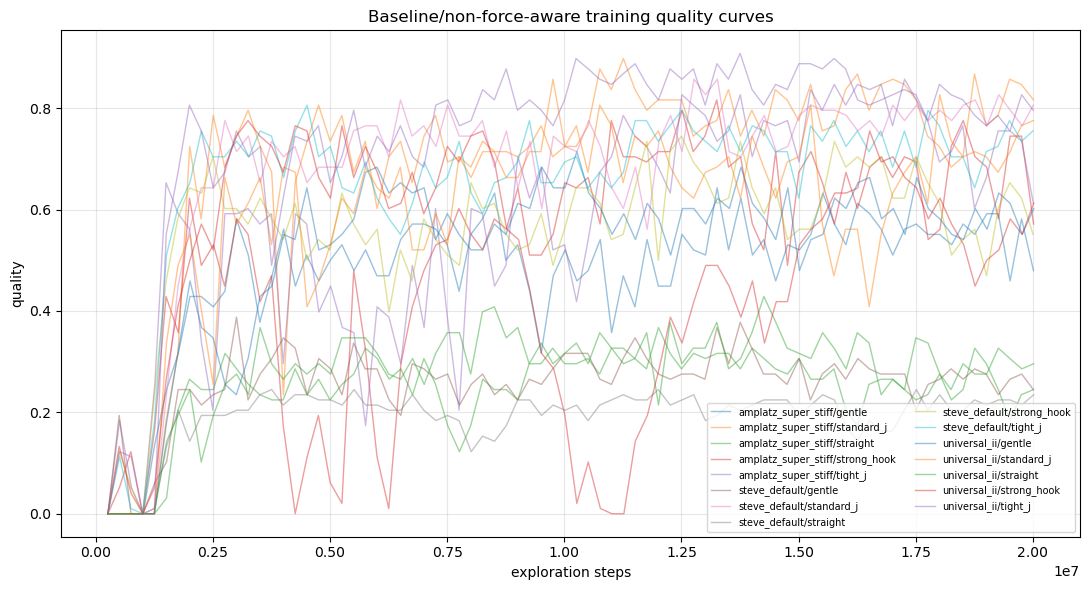

In [4]:
if run_df.empty:
    display(Markdown("No merged training runs found."))
else:
    best_table = run_df.sort_values(["training_type", "wire_model", "wire_shape", "alpha"])[
        [
            "training_type",
            "wire_model",
            "wire_shape",
            "alpha",
            "n_stages",
            "n_checkpoints",
            "max_checkpoint_step",
            "best_quality",
            "best_reward",
            "best_exploration_steps",
            "has_best_checkpoint",
        ]
    ]
    display(Markdown("### Best checkpoint summary per merged run"))
    display(
        best_table.style.format(
            {
                "max_checkpoint_step": "{:.0f}",
                "best_quality": "{:.4f}",
                "best_reward": "{:.4f}",
                "best_exploration_steps": "{:.0f}",
            },
            na_rep="",
        )
    )

if not eval_df.empty:
    fig, ax = plt.subplots(figsize=(11, 6))
    baseline = eval_df[eval_df["training_type"].eq("non_force_aware")]
    for execution_wire, group in baseline.groupby("execution_wire"):
        group = group.sort_values("exploration_steps")
        ax.plot(group["exploration_steps"], group["quality"], alpha=0.45, linewidth=1, label=execution_wire)
    ax.set_title("Baseline/non-force-aware training quality curves")
    ax.set_xlabel("exploration steps")
    ax.set_ylabel("quality")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


## 4. Next Analysis Ideas

- Compare baseline `standard_j` against force-aware `standard_j` for each wire model and alpha.
- Join `run_df` with E1/E2 evaluation metrics through `execution_wire`.
- Plot training quality versus E2 success/force-safe success.
- Inspect whether force-aware training reduces force metrics without destroying success.
- Compare the selected `best_checkpoint.everl` against the latest checkpoint for each run.
